In [1]:
from pathlib import Path
from platform import python_version
import importlib
import logging
import sys
import os

logging.basicConfig(
    format="%(levelname)s: %(message)s", stream=sys.stdout, level=logging.INFO
)
logger = logging.getLogger("__notebook__")
logger.info("Interpreting with python {}".format(python_version()))
# Loading markov model directory as module into jupyter notebook
module_dir = Path(os.getcwd()).parent.resolve()
data_dir = module_dir / "data"
logger.info(f"Module directory: {module_dir}")

if str(module_dir) not in sys.path:
    sys.path.insert(1, str(module_dir))
    logger.info("Markov Module path inserted into system path, ready to use")
else:
    logger.info("Markov Module path already inserted into system paths")

# Temp solution to load as module
try:
    from model import markov_chain as mc
    from model import probabilistic_analysis as psa
    from model import visualization
    from model import constants
    from model import utils

    # Force to update module
    importlib.reload(mc)
    importlib.reload(psa)
    importlib.reload(visualization)
    importlib.reload(constants)
    importlib.reload(utils)
    logger.info("Module reloaded")
except ModuleNotFoundError as e:
    logger.error(f"Unable to import module: {e.msg}")

INFO: Interpreting with python 3.13.8
INFO: Module directory: /home/mohammad/projects/Thesis/hemophilia
INFO: Markov Module path inserted into system path, ready to use
INFO: Module reloaded


In [2]:
import numpy as np


logger.info(
    """\n
    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
"""
)

# INPUTS
sobol_sample_size = 512  # simulated sample final count follows: N * (D + 2)
n_cycles = constants.LONG_TERM_CYCLE_COUNTS
ssp = constants.SHORT_SIMULATION_START_AGE_IN_WEEK  # simulation starting point
estate = constants.START_STATE  # entrance state
stats = constants.STATES

logger.info(
    f"""
    Model initialized with:
    - Base sample size: {sobol_sample_size}
    - Simulation steps: {n_cycles} ({n_cycles / constants.WOY} Years)
    - Simulation starting point: {ssp} ({ssp / constants.WOY} YO)
    """
)

chains = []
chain_main = mc.Chain(
    name="main",
    states=stats,
    matrix=np.eye(N=len(stats), M=len(stats), dtype=np.float64),
)
chains.append(chain_main)

INFO: 

    Simplified Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------

INFO: 
    Model initialized with:
    - Base sample size: 512
    - Simulation s

INFO: Sampling ABR values took 1.24 seconds
INFO: Generated data length: 11264


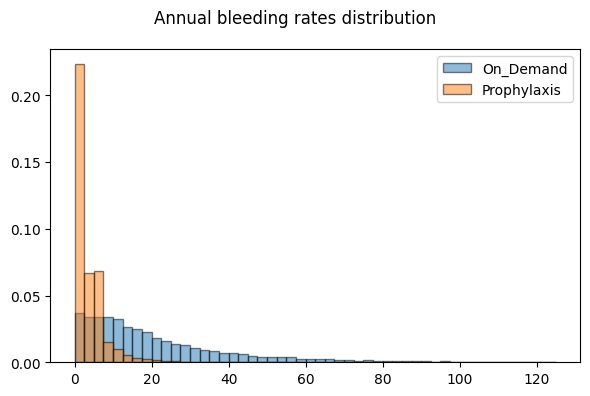

In [3]:
# Short term simulation
from time import time
import matplotlib.pyplot as plt
import seaborn as sns
import model.dtypes as dtypes  # defined types

start = time()
# Note: For the sake of statistical comparison n_samples should be in same size over different population in each treatment arms
on_demand_sampled_abr = psa.sample_population_abrs(
    treatment=dtypes.Treatment.ON_DEMAND,
    n_samples=sobol_sample_size,
    visualize=False,
)
prophylaxis_sampled_abr = psa.sample_population_abrs(
    treatment=dtypes.Treatment.PROPHYLAXIS,
    n_samples=sobol_sample_size,
    visualize=False,
)
exc_time = round((time() - start), 2)
logger.info(f"Sampling ABR values took {exc_time} seconds")
logger.info(f"Generated data length: {len(on_demand_sampled_abr)}")

# Drawing population ABR distribution
plt.figure(figsize=(6, 4))
plt.suptitle("Annual bleeding rates distribution")
on_demand_hist = plt.hist(
    on_demand_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="On_Demand",
)
prophylaxis_hist = plt.hist(
    prophylaxis_sampled_abr,
    50,
    range=(0, 125),
    density=True,
    alpha=0.5,
    edgecolor="black",
    label="Prophylaxis",
)
plt.legend()
plt.tight_layout()

INFO: Patients average weight: 66.9 kg


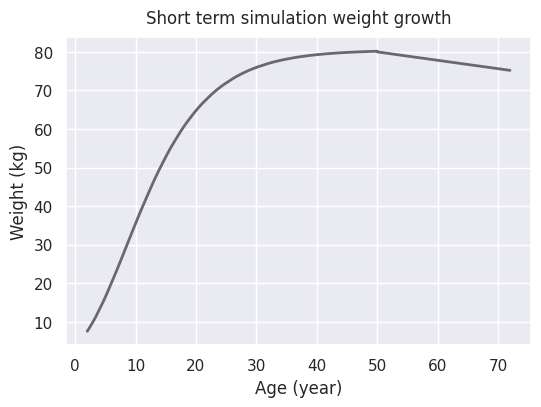

In [4]:
weights = [utils.cal_body_weight(n, b=ssp) for n in range(n_cycles)]
pairs: dict[int, float] = {(i + ssp): weight for i, weight in enumerate(weights)}
average_weight = np.mean(list(pairs.values()))

logger.info(f"Patients average weight: {round(average_weight, 2)} kg")

# Drawing patient weight growth graph
sns.set_theme()
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
X = np.array(list(pairs.keys()))
Y = np.array(list(pairs.values()))
ax.plot(X / constants.WOY, Y, color="dimgray", linestyle="-", linewidth=2)
text = ax.set_title("Short term simulation weight growth", pad=10)
y_text = ax.set_ylabel("Weight (kg)")
x_text = ax.set_xlabel("Age (year)")

In [ ]:
import model.markov_chain

# Defining markov chains instance
markov = mc.MarkovChains(
    chains=chains,
    entrance="Healthy",
    entrance_chain="main",
    steps=n_cycles,
    conditions=None,
)
logger.info(f"Starting simulations for {n_cycles} steps (weeks)")
# Defining markov models single simulation arguments array
on_demand_hemophilia_inputs = [
    dtypes.HemophiliaInput(
        treatment=dtypes.Treatment.ON_DEMAND,
        abr=abr,
        ajbr=None,
        wbr=None,
        webr=None,
        wjbr=None,
    )
    for abr in on_demand_sampled_abr
]
prophylaxis_hemophilia_inputs = [
    dtypes.HemophiliaInput(
        treatment=dtypes.Treatment.PROPHYLAXIS,
        abr=abr,
        ajbr=None,
        wbr=None,
        webr=None,
        wjbr=None,
    )
    for abr in prophylaxis_sampled_abr
]
# Running and storing simulation results
on_demand_results = model.markov_chain.parallelize_markov_chain(
    simulation_name="on_demand",
    worker_inputs=on_demand_hemophilia_inputs,
    worker_func=psa.worker_function,
    markov_chain=markov,
)
prophylaxis_results = model.markov_chain.parallelize_markov_chain(
    simulation_name="prophylaxis",
    worker_inputs=prophylaxis_hemophilia_inputs,
    worker_func=psa.worker_function,
    markov_chain=markov,
)

INFO: Starting simulations for 3640 steps (weeks)


In [6]:
# Unwrap input outputs from markov model simulation results
on_demand_inputs, on_demand_outputs = on_demand_results
prophylaxis_inputs, prophylaxis_outputs = prophylaxis_results

In [7]:
SAMPLE_SIZE = len(on_demand_sampled_abr)
logger.info(f"{SAMPLE_SIZE:,} data generated to work with")

cols = list(psa.HemophiliaOutput.model_fields.keys())
cols.insert(0, "regimes")
cols.insert(1, "input_abr")

for key in ["arthropathy", "is_dead", "weights", "mean_weight", "person_year"]:
    cols.append(key)

logger.info("Dataframe Columns: \n {}".format(cols).replace(",", ",\n"))

INFO: 11,264 data generated to work with
INFO: Dataframe Columns: 
 ['regimes',
 'input_abr',
 'initial_state',
 'final_state',
 'steps',
 'path',
 'factor_consumption',
 'factor_costs',
 'annual_factor_consumption',
 'annual_factor_costs',
 'hemarthrosis',
 'qaly',
 'abr',
 'pettersson_score',
 'arthropathy',
 'is_dead',
 'weights',
 'mean_weight',
 'person_year']


In [ ]:
import pandas as pd
import numpy as np


def truncate_weights_at_death(sequences: list["str"]):
    death_indices = [
        i
        for i, state in enumerate(sequences)
        if state
        and any(
            "death" in str(s).lower()
            for s in (state if isinstance(state, (list, tuple)) else [state])
        )
    ]

    if death_indices:
        # Use the first death occurrence
        death_index = death_indices[0]
        return weights[: death_index + 1]  # Include the death state

    # If no death found, return full weights
    return weights


def to_stage(pettersson_score_sequence: list[int | float] | np.ndarray):
    if isinstance(pettersson_score_sequence, list):
        pettersson_score_sequence = np.array(pettersson_score_sequence)
    if len(pettersson_score_sequence.shape) > 1:
        raise ValueError(
            f"Pettersson score array should be 1-D, shape: {pettersson_score_sequence.shape}"
        )
    if np.all(pettersson_score_sequence == 0):
        return "healthy"
    max_score = pettersson_score_sequence.max()
    if max_score < 0:
        raise ValueError("Invalid pettersson score")
    if max_score > 28:
        return "severe"
    elif max_score > 5:
        return "moderate"
    elif max_score <= 5:
        return "mild"
    else:
        raise ValueError(f"No stage defined for pettersson score: {max_score}")


start = time()
on_demand_df = pd.DataFrame(
    columns=cols,
    data={
        "regimes": "on_demand",
        "initial_state": [op.initial_state for op in on_demand_outputs],
        "final_state": [op.final_state for op in on_demand_outputs],
        "steps": [op.steps for op in on_demand_outputs],
        "input_abr": [op["abr"] for op in on_demand_inputs],
        "abr": [op.abr for op in on_demand_outputs],
        "hemarthrosis": [op.hemarthrosis for op in on_demand_outputs],
        "factor_consumption": [op.factor_consumption for op in on_demand_outputs],
        "qaly": [op.qaly for op in on_demand_outputs],
        "factor_costs": [op.factor_costs for op in on_demand_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in on_demand_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in on_demand_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in on_demand_outputs],
        "pettersson_score": [op.pettersson_score for op in on_demand_outputs],
        "is_dead": [True if "Death" in op.path else False for op in on_demand_outputs],
        "path": [op.path for op in on_demand_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in on_demand_outputs],
    },
)

# ---- Dependent columns assignment ----
mean_weight = lambda x: round(np.array(x).mean(), 2)  # noqa: E731
person_year = lambda x: round(len(x) / constants.WOY, 2)  # noqa: E731

on_demand_df["mean_weight"] = on_demand_df["weights"].apply(mean_weight)
on_demand_df["person_year"] = on_demand_df["weights"].apply(person_year)
exc_time = round((time() - start), 2)
logger.info(f"Loading on_demand data with pandas took {exc_time} seconds")

start = time()
prophylaxis_df = pd.DataFrame(
    data={
        "regimes": "prophylaxis",
        "input_abr": [op["abr"] for op in prophylaxis_inputs],
        "initial_state": [op.initial_state for op in prophylaxis_outputs],
        "final_state": [op.final_state for op in prophylaxis_outputs],
        "steps": [op.steps for op in prophylaxis_outputs],
        "abr": [op.abr for op in prophylaxis_outputs],
        "hemarthrosis": [op.hemarthrosis for op in prophylaxis_outputs],
        "factor_consumption": [op.factor_consumption for op in prophylaxis_outputs],
        "qaly": [op.qaly for op in prophylaxis_outputs],
        "factor_costs": [op.factor_costs for op in prophylaxis_outputs],
        "annual_factor_consumption": [
            op.annual_factor_consumption for op in prophylaxis_outputs
        ],
        "annual_factor_costs": [op.annual_factor_costs for op in prophylaxis_outputs],
        "pettersson_score": [op.pettersson_score for op in prophylaxis_outputs],
        "arthropathy": [to_stage(op.pettersson_score) for op in prophylaxis_outputs],
        "is_dead": [
            True if "Death" in op.path else False for op in prophylaxis_outputs
        ],
        "path": [op.path for op in prophylaxis_outputs],
        "weights": [truncate_weights_at_death(op.path) for op in prophylaxis_outputs],
    },
    columns=cols,
)
prophylaxis_df["mean_weight"] = prophylaxis_df["weights"].apply(mean_weight)
prophylaxis_df["person_year"] = prophylaxis_df["weights"].apply(person_year)
exc_time = round((time() - start), 2)
logger.info(f"loading prophylaxis data with pandas took {exc_time} seconds")

df_merged = pd.concat([on_demand_df, prophylaxis_df])

# NOTE:
# revise mean_weight to use peron_year instead of constant value
# ---- Preprocessing ----
unnecessary_columns = ["initial_state", "steps", "path", "weights", "pettersson_score"]
df = df_merged.drop(columns=unnecessary_columns)
df = df.apply(lambda x: round(x, 2) if pd.api.types.is_numeric_dtype(x) else x)
df.sample(n=5).head()


INFO: Loading on_demand data with pandas took 39.92 seconds
INFO: loading prophylaxis data with pandas took 41.36 seconds


,regimes,input_abr,final_state,factor_consumption,factor_costs,annual_factor_consumption,annual_factor_costs,hemarthrosis,qaly,abr,arthropathy,is_dead,mean_weight,person_year
4168,on_demand,13.32,Death,1570844.0,106727.32,22440.63,1524.68,4.71,21.42,4.69,moderate,True,50.42,28.56
11126,on_demand,3.25,Death,244851.0,16635.83,3497.87,237.65,0.60,14.62,0.60,mild,True,36.95,17.35
6996,on_demand,33.36,Death,4053238.0,275387.78,57903.40,3934.11,13.56,18.60,13.09,severe,True,50.33,28.46
3479,prophylaxis,2.89,Healthy,19516606.0,1326010.15,278808.66,18943.00,2.97,56.59,3.00,moderate,False,66.90,70.00
10684,on_demand,18.31,Death,4395587.0,298647.88,62794.10,4266.40,11.30,30.95,11.67,severe,True,60.38,44.10


In [9]:
f2 = lambda x: round(x, 2)  # noqa: E731
df_alive = df[df.final_state != "Death"]
abr_absolute_difference = np.abs(df_alive["abr"] - df_alive["input_abr"])
# Sums
logger.info(
    f"""
    Mean absolute differences of simulated annual bleeding rate vs model input ABR values: {f2(abr_absolute_difference.mean())}, ({f2(abr_absolute_difference.std())})
    """
)

INFO: 
    Mean absolute differences of simulated annual bleeding rate vs model input ABR values: 0.19, (0.28)
    


In [10]:
# TODO: Visualize model generated transition matrix, or store them as csv files

In [11]:
SIMULATED_YEARS = int(n_cycles / constants.WOY)
# Converts cumulative results to annual value
per_year = lambda x: x / SIMULATED_YEARS  # noqa: E731

MORT_RATE_OD = on_demand_df.is_dead.mean() * 100
MORT_RATE_PRO = prophylaxis_df.is_dead.mean() * 100
# Relative mortality reduction
RRR = (MORT_RATE_OD - MORT_RATE_PRO) / MORT_RATE_OD * 100
PREVENTED_DEATH = on_demand_df.is_dead.sum() - prophylaxis_df.is_dead.sum()
PREVENTED_DEATH_PER_1000P = PREVENTED_DEATH / SAMPLE_SIZE * 1000

ANNUAL_BLEED_PREVENTED = round(on_demand_df.abr.sum() - prophylaxis_df.abr.sum())
RELATIVE_ABR_REDUCTION = round(ANNUAL_BLEED_PREVENTED / on_demand_df.abr.sum() * 100)

# Factor consumption ratio
FCR = prophylaxis_df.factor_consumption.sum() / on_demand_df.factor_consumption.sum()

# Delta values
DC = f2(prophylaxis_df.factor_costs.sum() - on_demand_df.factor_costs.sum())
DQ = f2(prophylaxis_df.qaly.sum() - on_demand_df.qaly.sum())
LG = f2(prophylaxis_df.person_year.sum() - on_demand_df.person_year.sum())
ICER_QALY = f2(DC / DQ)
ICER_LG = f2(DC / LG)
ACCEPTABLE_EXPENDITURE = constants.WTP_THRESHOLD * (DQ)
NMB = f2(ACCEPTABLE_EXPENDITURE - DC)

logger.info(
    f"""
    Population size (simulations): {SAMPLE_SIZE:,}
    Simulation length (year): {SIMULATED_YEARS}
    Increased factor costs: ${round(DC):,}
    Increased QALY: {DQ:,}
    Relative ABR reduction: {f2(RELATIVE_ABR_REDUCTION)}%
    Relative mortality reduction: {round(RRR)}%
    Number of death prevented (per 1000 case): {round(PREVENTED_DEATH_PER_1000P)}
    Life years gained: {LG:,}
    
    [Annual]
    Annual increased factor cost: ${round(per_year(DC)):,}
    Annual bleeds prevented: {ANNUAL_BLEED_PREVENTED:,}
    
    [Economic indicators]
    Factor consumption: {f2(FCR)} folds increase
    Cost per bleed prevented: ${round(per_year(DC) / ANNUAL_BLEED_PREVENTED)}
    Incremental cost effectiveness ratio (DC/QALY): ${int(ICER_QALY):,}
    Incremental cost effectiveness ratio (DC/LYG): ${int(ICER_LG):,}
    Net monetary benefits: ${round(NMB):,}
    
    Conclusion: Intervention {"was not" if NMB < 0 else "was"} cost effective
    """
)

INFO: 
    Population size (simulations): 11,264
    Simulation length (year): 70
    Increased factor costs: $8,381,893,482
    Increased QALY: 210,224.88
    Relative ABR reduction: 67%
    Relative mortality reduction: 37%
    Number of death prevented (per 1000 case): 305
    Life years gained: 216,969.06
    
    [Annual]
    Annual increased factor cost: $119,741,335
    Annual bleeds prevented: 40,353
    
    [Economic indicators]
    Factor consumption: 7.3 folds increase
    Cost per bleed prevented: $2967
    Incremental cost effectiveness ratio (DC/QALY): $39,871
    Incremental cost effectiveness ratio (DC/LYG): $38,631
    Net monetary benefits: $-5,372,692,505
    
    Conclusion: Intervention was not cost effective
    


In [ ]:
per_kg = lambda x: x / np.array(weights).mean()  # noqa: E731
logger.info(
    f"""
    [On Demand]
    ABR: {f2(on_demand_df.input_abr.mean())} ({f2(on_demand_df.input_abr.std())})
    Median life time bleeds count: {f2(on_demand_df.abr.median() * on_demand_df.person_year.median())} # Check formula
    Mean annual factor consumption per mean weight (IU/KG): {round(per_kg(on_demand_df.annual_factor_consumption.mean())):,} ({round(per_kg(on_demand_df.annual_factor_consumption.std())):,})
    Mean annual factor cost per mean weight ($/KG): ${round(per_kg(on_demand_df.annual_factor_costs.mean())):,} ({round(per_kg(on_demand_df.annual_factor_costs.std())):,})
    Death (includes natural cause of death): {f2(MORT_RATE_OD)}%
    Joint outcome:
        - Healthy: {round(f2(on_demand_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {round(f2(on_demand_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {round(f2(on_demand_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {round(f2(on_demand_df.arthropathy.str.count("severe").mean()) * 100)}%
    
    [Prophylaxis]
    ABR: {f2(prophylaxis_df.input_abr.mean())} ({f2(prophylaxis_df.input_abr.std())})
    Median life time bleeds count: {f2(prophylaxis_df.abr.median() * prophylaxis_df.person_year.median())} # Check formula
    Mean factor consumption per mean weight (IU/KG): {round(per_kg(prophylaxis_df.annual_factor_consumption.mean())):,} ({round(per_kg(prophylaxis_df.annual_factor_consumption.std())):,})
    Mean annual factor cost per mean weight ($/KG): ${round(per_kg(prophylaxis_df.annual_factor_costs.mean())):,} ({round(per_kg(prophylaxis_df.annual_factor_costs.std())):,})
    Death (includes natural cause of death): {f2(MORT_RATE_PRO)}%
    Joint outcome:
        - Healthy: {round(f2(prophylaxis_df.arthropathy.str.count("healthy").mean()) * 100)}%
        - Mild arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("mild").mean()) * 100)}%
        - Moderate arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("moderate").mean()) * 100)}%
        - Severe arthropathy: {round(f2(prophylaxis_df.arthropathy.str.count("severe").mean()) * 100)}%
    """
)

# Burden of disease

INFO: 
    [On Demand]
    ABR: 21.55 (21.01)
    Median life time bleeds count: 72.29
    Mean annual factor consumption per mean weight (IU/KG): 371 (484)
    Mean annual factor cost per mean weight ($/KG): $25 (33)
    Death (includes natural cause of death): 83.22%
    Joint outcome:
        - Healthy: 3%
        - Mild arthropathy: 20%
        - Moderate arthropathy: 47%
        - Severe arthropathy: 29%
    
    [Prophylaxis]
    ABR: 3.47 (4.41)
    Median life time bleeds count: 58.41
    Mean factor consumption per mean weight (IU/KG): 2,710 (1,602)
    Mean annual factor cost per mean weight ($/KG): $184 (109)
    Death (includes natural cause of death): 52.73%
    Joint outcome:
        - Healthy: 19%
        - Mild arthropathy: 40%
        - Moderate arthropathy: 38%
        - Severe arthropathy: 4%
    


In [13]:
logger.info("Bootstrapping model outputs to calculate ICER IQR and STD")
BOOTSTRAP_ICERS = []
BOOTSTRAP_ITER = 5000
start = time()
for _ in range(BOOTSTRAP_ITER):
    od_sample = on_demand_df.sample(n=SAMPLE_SIZE, replace=True)
    pro_sample = prophylaxis_df.sample(n=SAMPLE_SIZE, replace=True)
    BOOTSTRAP_DC = pro_sample["factor_costs"].sum() - od_sample["factor_costs"].sum()
    BOOTSTRAP_DQ = pro_sample["qaly"].sum() - od_sample["qaly"].sum()
    if np.isfinite(BOOTSTRAP_DC) and np.isfinite(BOOTSTRAP_DQ) and BOOTSTRAP_DQ != 0:
        BOOTSTRAP_ICERS.append(BOOTSTRAP_DC / BOOTSTRAP_DQ)
exc_time = round(time() - start, 2)
logger.info(f"Bootstrapping with {BOOTSTRAP_ITER} iterations took {exc_time} seconds")

INFO: Bootstrapping model outputs to calculate ICER IQR and STD
INFO: Bootstrapping with 5000 iterations took 29.53 seconds


INFO: Median (IQR): $39,876 (563)


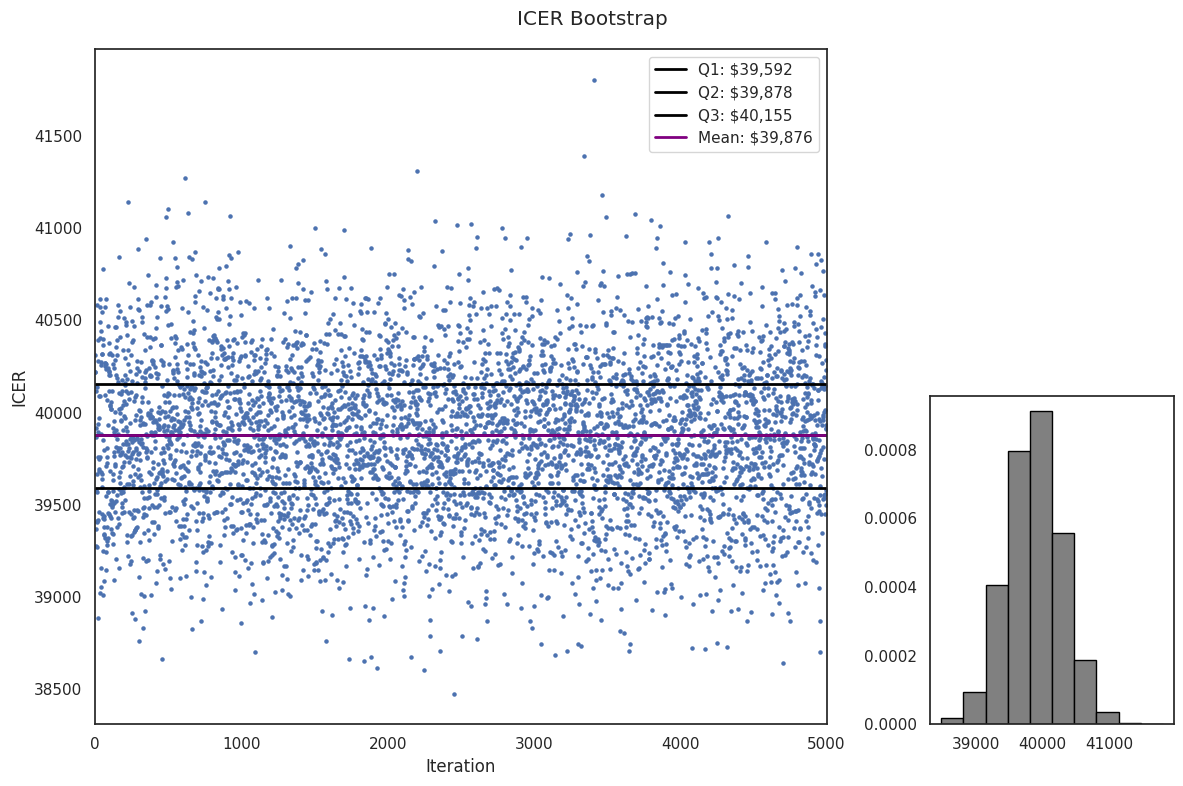

In [14]:
from matplotlib.gridspec import GridSpec

# ---- Plots Configs ----
sns.set_theme(style="white")
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))
scatter = fig.add_subplot(gs[:, :-1])
hist = fig.add_subplot(gs[-1, -1])

# ---- PLOTS ----
X = [i for i in range(len(BOOTSTRAP_ICERS))]
scatter.scatter(X, BOOTSTRAP_ICERS, s=5)
hist.hist(BOOTSTRAP_ICERS, color="gray", density=True, edgecolor="black")


BQ1 = np.percentile(BOOTSTRAP_ICERS, 25).astype(float)
BQ2 = np.percentile(BOOTSTRAP_ICERS, 50).astype(float)
BQ3 = np.percentile(BOOTSTRAP_ICERS, 75).astype(float)
BOOTSTRAP_MEAN_ICER = np.mean(BOOTSTRAP_ICERS)

scatter.axhline(BQ1, color="black", linewidth=2, label=f"Q1: ${round(BQ1):,}")
scatter.axhline(BQ2, color="black", linewidth=2, label=f"Q2: ${round(BQ2):,}")
scatter.axhline(BQ3, color="black", linewidth=2, label=f"Q3: ${round(BQ3):,}")
scatter.axhline(
    float(BOOTSTRAP_MEAN_ICER),
    color="purple",
    linewidth=2,
    label=f"Mean: ${round(BOOTSTRAP_MEAN_ICER):,}",
)
scatter.set_xlim(left=0, right=len(BOOTSTRAP_ICERS))
scatter.set_ylabel("ICER")
scatter.set_xlabel("Iteration")
scatter.legend()
fig.suptitle("ICER Bootstrap")
fig.tight_layout()

logger.info(f"Median (IQR): ${round(BOOTSTRAP_MEAN_ICER):,} ({round(BQ3 - BQ1):,})")

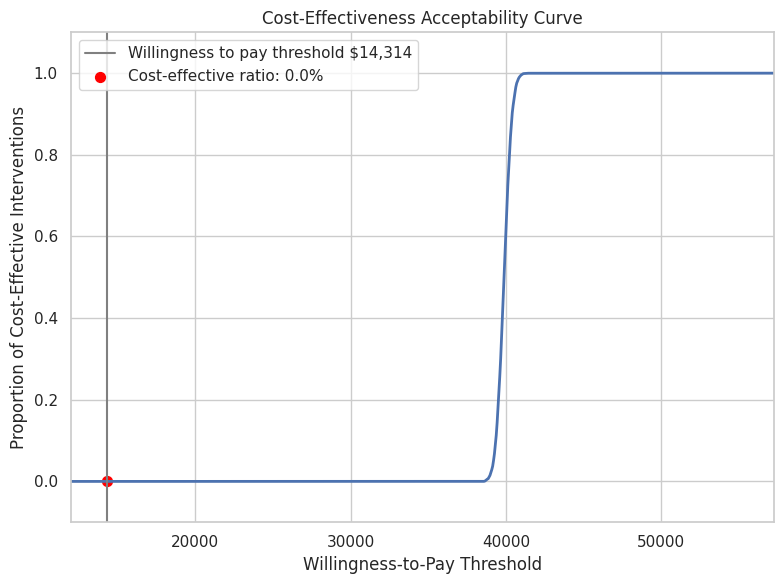

In [15]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 4
X = np.linspace(start=0, stop=max_threshold, num=1000)
Y = []

for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(BOOTSTRAP_ICERS <= threshold)
    ratio = cost_effective_count / len(BOOTSTRAP_ICERS)
    Y.append(ratio)

below_threshold_icers = np.array(BOOTSTRAP_ICERS) <= constants.WTP_THRESHOLD
cost_effective_ratio = np.sum(below_threshold_icers / len(BOOTSTRAP_ICERS))

# Plot Acceptability Curve
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(
    x=constants.WTP_THRESHOLD,
    color="gray",
    label=f"Willingness to pay threshold ${round(constants.WTP_THRESHOLD):,}",
)
ax.scatter(
    x=constants.WTP_THRESHOLD,
    y=cost_effective_ratio,
    color="red",
    s=50,
    label=f"Cost-effective ratio: {round(cost_effective_ratio, 2)}%",
)
ax.set_xlabel("Willingness-to-Pay Threshold")
ax.set_ylabel("Proportion of Cost-Effective Interventions")
ax.set_title("Cost-Effectiveness Acceptability Curve")
ax.set_xlim(12000, max_threshold)
ax.set_ylim(-0.1, 1.1)
ax.legend()
fig.tight_layout()

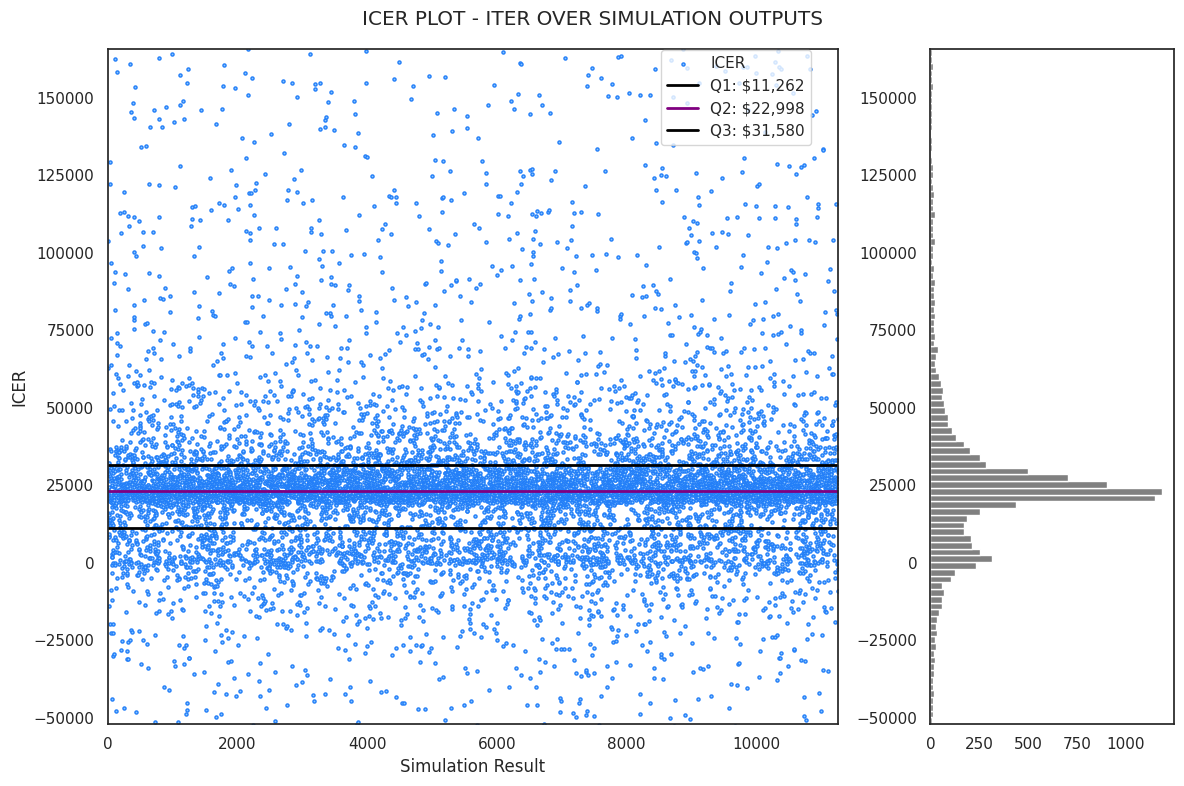

In [16]:
# sns.set_theme(style="darkgrid", rc={"axes.spines.right": False, "axes.spines.top": False})
sns.set_theme(style="white")
DC_SERIES = prophylaxis_df.factor_costs - on_demand_df.factor_costs
DQ_SERIES = prophylaxis_df.qaly - on_demand_df.qaly
# Avoid zero-division error
valid_mask = np.isfinite(DQ_SERIES) & np.isfinite(DC_SERIES) & (DQ_SERIES != 0)
ICERS_PER_SIMULATION = DC_SERIES[valid_mask] / DQ_SERIES[valid_mask]

fig = plt.figure(figsize=(12, 8))
gs = GridSpec(2, 2, width_ratios=(3, 1), height_ratios=(1, 1))

scatter = fig.add_subplot(gs[:, :-1])
hist = fig.add_subplot(gs[:, -1])

scatter.scatter(
    x=[i for i in range(len(ICERS_PER_SIMULATION))],
    y=ICERS_PER_SIMULATION,
    s=5,
    color="#88C6FF",
    edgecolors="#237FF8",
)
scatter.set_ylabel("ICER")
scatter.set_xlabel("Simulation Result")

BQ1 = np.percentile(ICERS_PER_SIMULATION, 25).astype(float)
BQ2 = np.percentile(ICERS_PER_SIMULATION, 50).astype(float)
BQ3 = np.percentile(ICERS_PER_SIMULATION, 75).astype(float)

P5 = np.percentile(ICERS_PER_SIMULATION, 5).astype(float)
P95 = np.percentile(ICERS_PER_SIMULATION, 95).astype(float)
TRUNC_ICERS = ICERS_PER_SIMULATION[
    (ICERS_PER_SIMULATION >= P5) & (ICERS_PER_SIMULATION <= P95)
]
hist.hist(TRUNC_ICERS, bins=100, color="gray", orientation="horizontal")
hist.set_ylim(bottom=P5, top=P95)

scatter.axhline(BQ1, color="black", linewidth=2)
scatter.axhline(BQ2, color="purple", linewidth=2)
scatter.axhline(BQ3, color="black", linewidth=2)
scatter.set_xlim(left=0, right=ICERS_PER_SIMULATION.shape[0])
scatter.set_ylim(bottom=P5, top=P95)
fig.suptitle("ICER plot - iter over simulation outputs".upper())
fig.legend(
    [
        "ICER",
        f"Q1: ${int(BQ1):,}",
        f"Q2: ${int(BQ2):,}",
        f"Q3: ${int(BQ3):,}",
    ],
    loc="upper center",
    bbox_to_anchor=(0.62, 0.94),
)
fig.tight_layout()

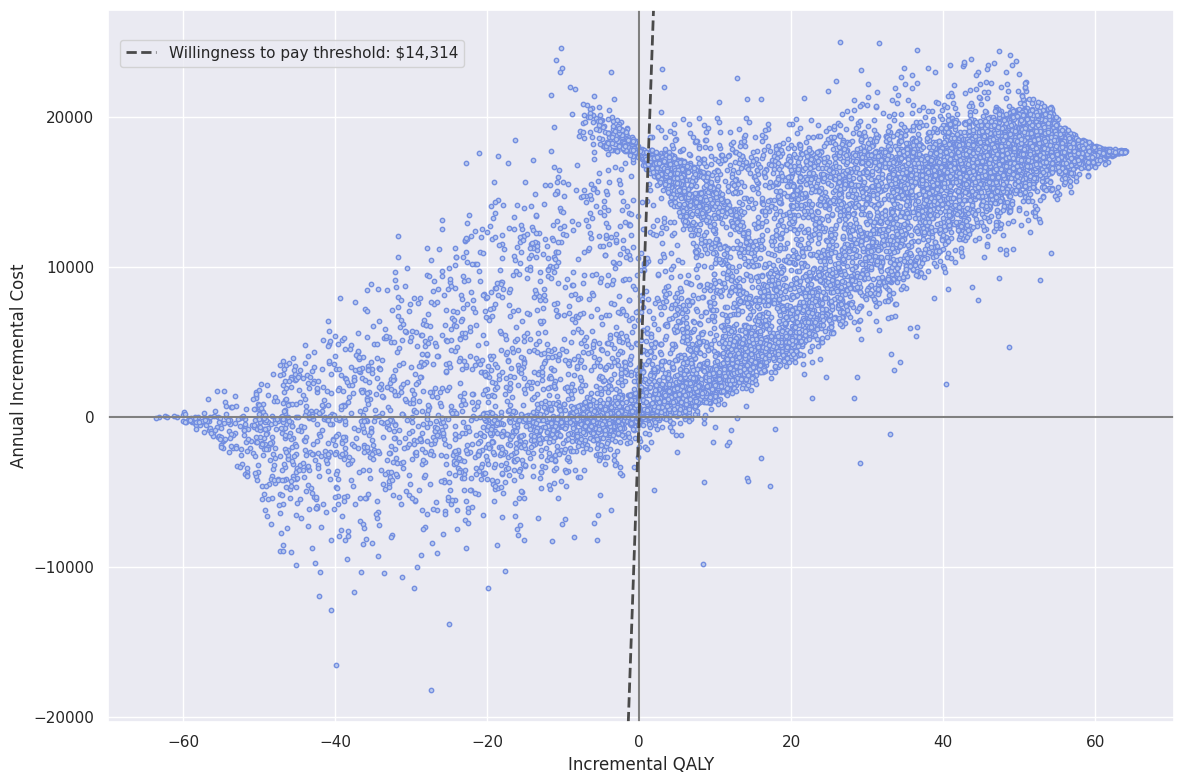

In [17]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.scatter(DQ_SERIES, per_year(DC_SERIES), s=10, edgecolor="#738EE0", color="#BACAED")
ax.set_xlabel("Incremental QALY")
ax.set_ylabel("Annual Incremental Cost")
ax.axvline(x=0, color="gray")
ax.axhline(y=0, color="gray")
ax.axline(
    (0, 0),
    slope=constants.WTP_THRESHOLD,
    color="#4A4A4A",
    linestyle="--",
    linewidth=2,
    label=f"Willingness to pay threshold: ${round(constants.WTP_THRESHOLD):,}",
)
fig.legend(loc="upper left", bbox_to_anchor=(0.10, 0.95))
fig.tight_layout()

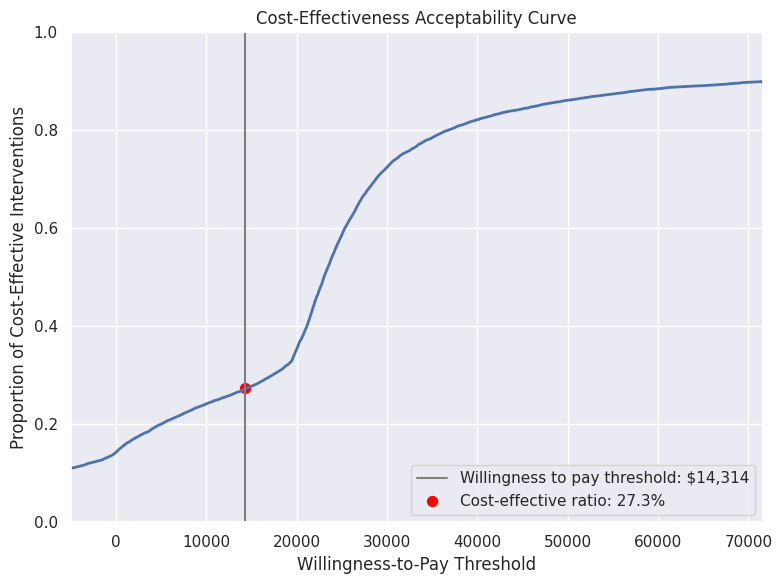

In [18]:
# Create WTP thresholds - consider making the upper bound more flexible
max_threshold = constants.WTP_THRESHOLD * 5
X = np.linspace(start=-5000, stop=max_threshold, num=1000)

Y = []
for threshold in X:
    # Below the current threshold
    cost_effective_count = np.sum(ICERS_PER_SIMULATION <= threshold)
    ratio = cost_effective_count / len(ICERS_PER_SIMULATION)
    Y.append(ratio)

# Point
cost_effective_count = np.sum(ICERS_PER_SIMULATION <= constants.WTP_THRESHOLD)
cost_effective_ratio = cost_effective_count / len(ICERS_PER_SIMULATION)

# Plot Acceptability Curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(X, Y, linewidth=2)
ax.axvline(
    x=constants.WTP_THRESHOLD,
    color="gray",
    label=f"Willingness to pay threshold: ${round(constants.WTP_THRESHOLD):,}",
)
ax.scatter(
    x=constants.WTP_THRESHOLD,
    y=cost_effective_ratio,
    color="red",
    s=50,
    label=f"Cost-effective ratio: {round(cost_effective_ratio * 100, 2)}%",
)
ax.set_xlabel("Willingness-to-Pay Threshold")
ax.set_ylabel("Proportion of Cost-Effective Interventions")
ax.set_title("Cost-Effectiveness Acceptability Curve")
ax.set_xlim(-5000, max_threshold)
ax.set_ylim(0, 1)
ax.legend()
fig.tight_layout()

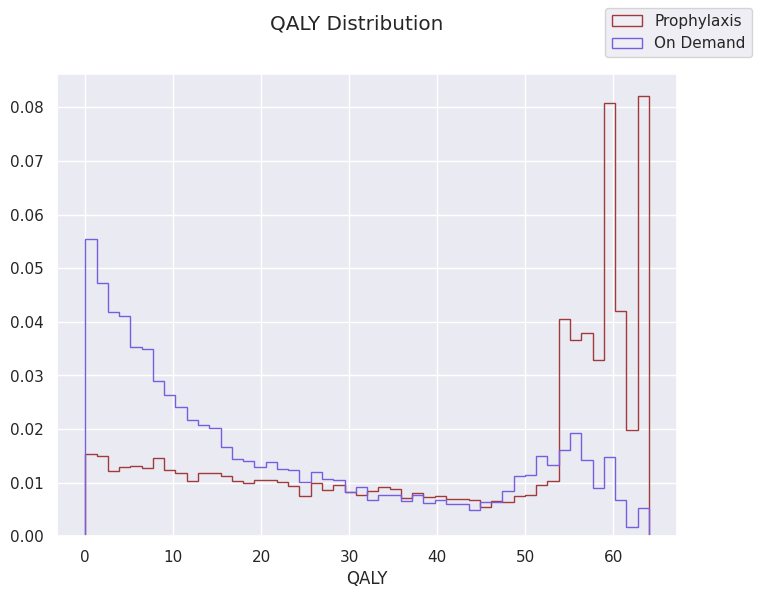

In [19]:
sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(
    x=[on_demand_df.qaly, prophylaxis_df.qaly],
    bins=50,
    histtype="step",
    stacked=False,
    color=["#765EDF", "#A13A3A"],
    label=["On Demand", "Prophylaxis"],
    density=True,
)
ax.set_xlabel("QALY")
fig.suptitle("QALY Distribution")
fig.legend()

Text(0.5, 0.98, 'Costs Distribution')

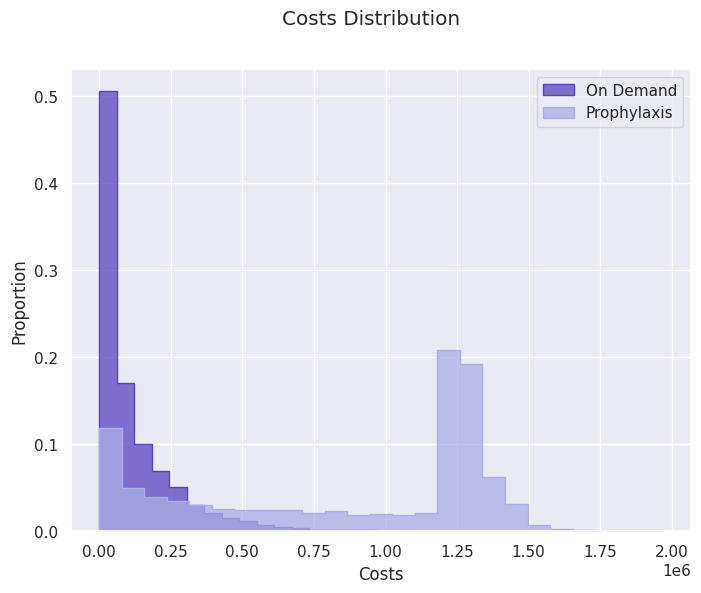

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(
    data=on_demand_df,
    x="factor_costs",
    bins=25,
    stat="probability",
    color="#5A43C0",
    label="On Demand",
    element="step",
    ax=ax,
)
sns.histplot(
    data=prophylaxis_df,
    x="factor_costs",
    bins=25,
    stat="probability",
    color="#ABAFE6",
    label="Prophylaxis",
    element="step",
    ax=ax,
)
ax.set_xlabel("Costs")
ax.set_ylabel("Proportion")
ax.legend()
fig.suptitle("Costs Distribution")

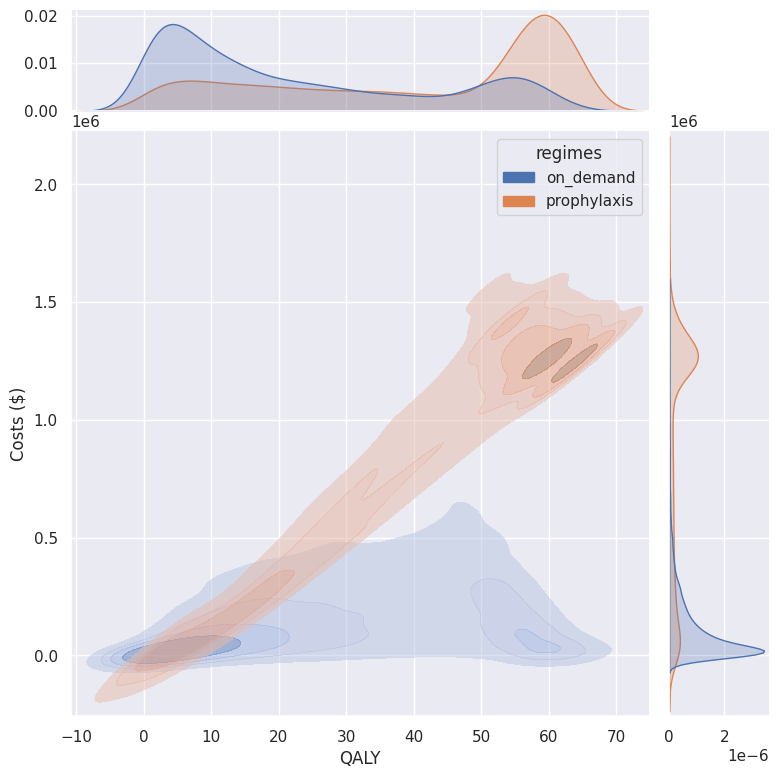

In [21]:
jg = sns.jointplot(
    data=df,
    x="qaly",
    y="factor_costs",
    hue="regimes",
    kind="kde",
    bw_adjust=0.8,
    height=8,
    palette=sns.color_palette("deep", 2),
    marginal_ticks=True,
    fill=True,
    alpha=0.5,
    levels=[0.04, 0.25, 0.5, 0.75, 1],
)
jg.set_axis_labels("QALY", "Costs ($)")

In [22]:
# Acceptable
od_acceptable = on_demand_df[on_demand_df.qaly > 50]
logger.info(
    f"""
    [Acceptable outcomes]
    On Demand patients had annual bleeding rate median: {f2(od_acceptable.input_abr.mean())} ({f2(od_acceptable.input_abr.std())}) got acceptable quality adjusted life year gains
    """
)

INFO: 
    [Acceptable outcomes]
    On Demand patients had annual bleeding rate median: 4.76 (3.8) got acceptable quality adjusted life year gains
    


INFO: ---- Priorities ----
INFO: Cluster 0: (15, 31)
INFO: Cluster 1: (6, 14)
INFO: Cluster 2: (0, 5)
INFO: Cluster 3: (32, 99)
INFO: ====================
INFO: Best fit model was lognormal
INFO: Lognormal: a * exp(-b * log(x + c)) + d ---> a: 28049032.10, b: 2.379, c: 21.2, d: 19908.76


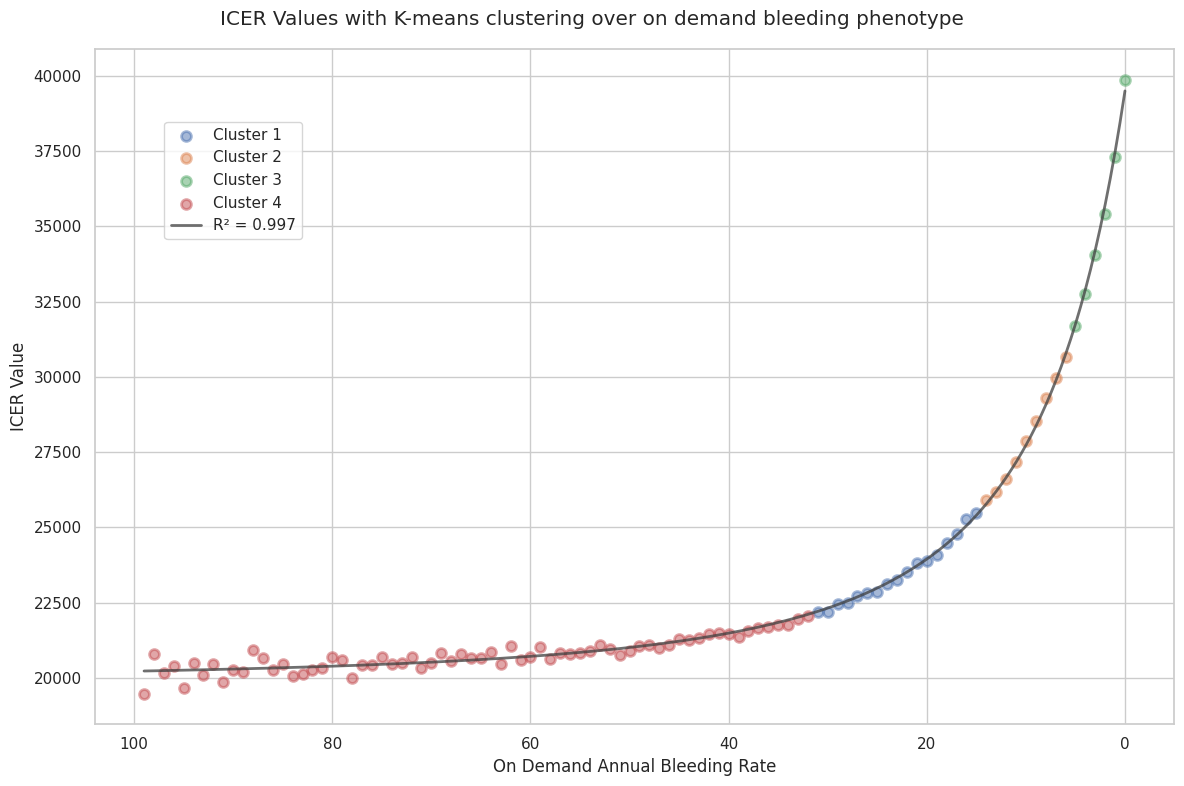

In [23]:
from scipy.cluster.vq import kmeans, vq
from scipy.optimize import curve_fit

# TODO: Fit lognormal

# ---- Sampling and selection ----
icer_selected = {}
for n in np.arange(0, min(100, on_demand_df.input_abr.max())):
    od_selection = on_demand_df[on_demand_df.input_abr >= n]
    pro_selection = prophylaxis_df.sample(len(od_selection))
    dcs = pro_selection.factor_costs.sum() - od_selection.factor_costs.sum()
    dqs = pro_selection.qaly.sum() - od_selection.qaly.sum()
    selected_icer = dcs / dqs
    icer_selected[n] = selected_icer

# ---- Clustering ----
k_value = 4
icer_values = np.array(list(icer_selected.values()))
centroids, distortion = kmeans(icer_values, k_value)

cluster_assignments, _ = vq(icer_values, centroids)
x_values = np.array(list(icer_selected.keys()))

# Filter out any NaN or infinite values for curve fitting
valid_mask = np.isfinite(icer_values)
x_fit = x_values[valid_mask]
y_fit = icer_values[valid_mask]

# Initialize variables
fit_successful = False
best_fit_type = None
best_r_squared = -np.inf
fit_results = {}


# Exponential fit
def exponential_func(x, a, b, c):
    """Exponential function: a * exp(b * x) + c"""
    return a * np.exp(b * x) + c


# Lognormal fit (modified)
def lognormal_func(x, a, b, c, d):
    """
    Lognormal model: a * exp(-b * log(x + c)) + d
    This creates a smooth decay that resembles lognormal behavior but works for any y-range
    """
    log_term = np.log(np.maximum(x + c, 0.1))
    return a * np.exp(-b * log_term) + d


# Try different fitting methods
x_fit_range = np.linspace(min(x_values), max(x_values), 200)
# 1. Exponential fit
try:
    if len(x_fit) > 3:
        # Try different initial guesses
        initial_guesses = [
            [np.mean(y_fit), 0.01, np.min(y_fit)],  # Small growth
            [np.mean(y_fit), -0.01, np.min(y_fit)],  # Decay
            [1, 0.1, np.mean(y_fit)],  # Original
        ]

        best_exp_r2 = -np.inf
        best_exp_params = None

        for p0 in initial_guesses:
            try:
                params, _ = curve_fit(
                    exponential_func,
                    x_fit,
                    y_fit,
                    p0=p0,
                    maxfev=10000,
                    bounds=([-np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf]),
                )
                y_pred = exponential_func(x_fit, *params)
                ss_res = np.sum((y_fit - y_pred) ** 2)
                ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                if r2 > best_exp_r2:
                    best_exp_r2 = r2
                    best_exp_params = params

            except Exception:
                continue

        if best_exp_params is not None:
            fit_results["exponential"] = {
                "params": best_exp_params,
                "r_squared": best_exp_r2,
                "curve": exponential_func(x_fit_range, *best_exp_params),
            }
            if best_exp_r2 > best_r_squared:
                best_r_squared = best_exp_r2
                best_fit_type = "exponential"

except Exception as e:
    logger.error(f"Exponential fit failed: {e}")

# 2. Lognormal fit
try:
    if len(x_fit) > 3:
        # Initial guesses for lognormal model
        initial_guesses = [
            [np.max(y_fit), 0.5, 1.0, np.min(y_fit)],  # Standard decay
            [np.max(y_fit) * 0.5, 0.3, 0.5, np.min(y_fit)],  # Slower decay
            [np.max(y_fit), 1.0, 2.0, np.min(y_fit)],  # Faster decay
        ]

        best_lognorm_r2 = -np.inf
        best_lognorm_params = None

        for p0 in initial_guesses:
            try:
                params, _ = curve_fit(
                    lognormal_func,
                    x_fit,
                    y_fit,
                    p0=p0,
                    maxfev=10000,
                    bounds=(
                        [0.01, 0.01, 0.01, -np.inf],
                        [np.inf, np.inf, np.inf, np.inf],
                    ),
                )
                y_pred = lognormal_func(x_fit, *params)
                ss_res = np.sum((y_fit - y_pred) ** 2)
                ss_tot = np.sum((y_fit - np.mean(y_fit)) ** 2)
                r2 = 1 - (ss_res / ss_tot)

                if r2 > best_lognorm_r2:
                    best_lognorm_r2 = r2
                    best_lognorm_params = params

            except Exception:
                continue

        if best_lognorm_params is not None:
            lognorm_curve = lognormal_func(x_fit_range, *best_lognorm_params)
            fit_results["lognormal"] = {
                "params": best_lognorm_params,
                "r_squared": best_lognorm_r2,
                "curve": lognorm_curve,
                "label": f"Lognormal-inspired (R²={best_lognorm_r2:.3f})",
            }
            if best_lognorm_r2 > best_r_squared:
                best_r_squared = best_lognorm_r2
                best_fit_type = "lognormal"

except Exception as e:
    logger.error(f"Lognormal-inspired fit failed: {e}")


# --- Plotting Section ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 8))

logger.info("---- Priorities ----")
for cluster_id in range(k_value):
    mask = cluster_assignments == cluster_id
    logger.info(
        f"Cluster {cluster_id}: ({np.min(x_values[mask])}, {np.max(x_values[mask])})"
    )
    ax.scatter(
        x=np.array(x_values)[mask],  # type: ignore
        y=icer_values[mask],
        alpha=0.5,
        s=50,
        label=f"Cluster {cluster_id + 1}",
        linewidth=2,
    )

logger.info("=" * 20)
# Plot best fit
fit_successful = len(fit_results) > 0
if fit_successful and best_fit_type in fit_results:
    best_result = fit_results[best_fit_type]
    logger.info("Best fit model was {}".format(best_fit_type))
    if best_fit_type == "lognormal":
        params = best_result["params"]
        logger.info(
            f"Lognormal: a * exp(-b * log(x + c)) + d ---> a: {params[0]:.2f}, b: {params[1]:.3f}, c: {params[2]:.1f}, d: {params[3]:.2f}"
        )
    elif best_fit_type == "exponential":
        params = best_result["params"]
        logger.info(
            f"Exponential: a(e)**(bx) + c ---> a: {f2(params[0])}, b: {f2(params[1])}, c: {f2(params[2])}"
        )
    ax.plot(
        x_fit_range,
        best_result["curve"],
        color="#3F3F3F",
        alpha=0.75,
        linewidth=2,
        label=f"R² = {best_result['r_squared']:.3f}",
    )

ax.set_xlabel("On Demand Annual Bleeding Rate")
ax.set_ylabel("ICER Value")
ax.invert_xaxis()
fig.suptitle("ICER Values with K-means clustering over on demand bleeding phenotype")
fig.legend(
    loc="upper right",
    bbox_to_anchor=(0.265, 0.85),
)
fig.tight_layout()

In [24]:
# Value to report:
# Report no. of factor viii infusions [ ]
# Report annual cost of factor viii / kg [ ]
# Report annual joint hemorrhages [ ]
# Budget impact [ ]
# Onset of arthropathy [ ]
# Number of treated bleeds [ ]
# Burden of disease [√]
# Report no. of factor viii unit infused [√]
# Report no. of factor viii unit infused per kg [√]
# Report annual bleeding rate [√]
# Report quality adjusted life year [√]
# Report Incremental cost effectiveness ratio [√]
# Report Net monetary benefit [√]